<a href="https://colab.research.google.com/github/kumarsusheel7497-collab/CODSOFT/blob/main/credit_scoring_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

========== CREDIT SCORING RESULTS ==========
Accuracy  : 0.8550
Precision : 0.7843
Recall    : 0.9195
F1 Score  : 0.8466
ROC AUC   : 0.8624


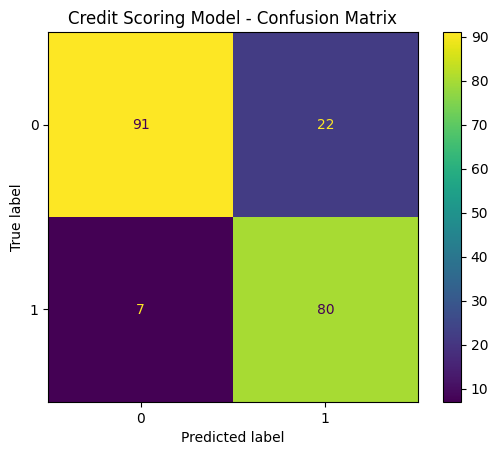


Customer is NOT CREDITWORTHY


In [1]:
# ==========================================
# CODEALPHA TASK 1
# CREDIT SCORING MODEL
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ==========================================
# CREATE SAMPLE CREDIT DATASET
# ==========================================

X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=6,
    n_redundant=2,
    random_state=42
)

# ==========================================
# SPLIT DATA
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ==========================================
# TRAIN MODEL
# ==========================================

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# ==========================================
# PREDICTIONS
# ==========================================

y_pred = model.predict(X_test)

# ==========================================
# EVALUATION
# ==========================================

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

print("========== CREDIT SCORING RESULTS ==========")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC AUC   : {roc_auc:.4f}")

# ==========================================
# CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Credit Scoring Model - Confusion Matrix")
plt.show()

# ==========================================
# SAMPLE PREDICTION
# ==========================================

sample_customer = X_test[0].reshape(1, -1)

prediction = model.predict(sample_customer)

if prediction[0] == 1:
    print("\nCustomer is CREDITWORTHY")
else:
    print("\nCustomer is NOT CREDITWORTHY")